In [26]:
#degree (hyper parameters)
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import numpy as np
data = pd.read_csv('./data/Housing.csv')

print(data.size)

X = data['area'].values
y = data['price'].values


X1_train, X1_test , y_train, y_test = train_test_split(
    X,y, test_size=0.1, random_state=42
)
def normalize(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())
  

# NORMAILZE
X_train = normalize(X1_train)
X_test = normalize(X1_test)


y_train = normalize(y_train)
y_test = normalize(y_test)

print(X_train[:5])
print(X_test[:5])

print(y_train[:5])
print(y_test[:5])


94981
[0.28634949 0.8921743  0.5222321  0.02823477 0.00177857]
[0.68911686 0.44090098 0.05508475 0.3719893  0.51092774]
[0.31069471 0.84757693 0.52295643 0.03754057 0.09725749]
[0.69939106 0.47821536 0.01667502 0.35771184 0.51378737]


In [27]:
features = np.array((
    X_train,
    X_train**2,
    np.ones(len(X_train))
)).T

In [28]:
parameters = np.zeros(features.shape[1])

In [29]:
learning_rate = 0.1
epochs = 500
n = len(y_train)

for i in range(epochs):
    y_pred = np.dot(features, parameters)

    gradient = (2/n) * np.dot(features.T, (y_pred - y_train))

    parameters = parameters - learning_rate * gradient

print(parameters)

[0.53451909 0.32463182 0.12173702]


In [30]:
y_pred = np.dot(features, parameters)

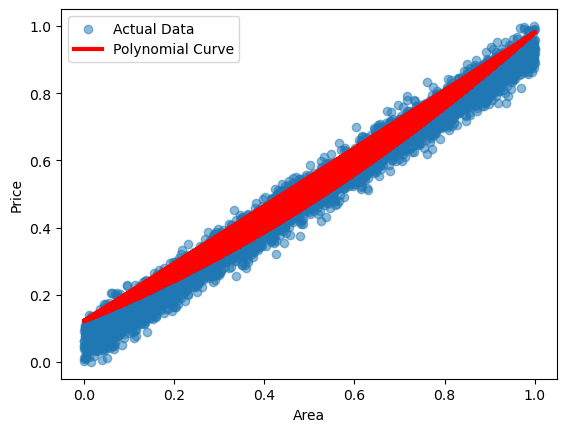

In [31]:
plt.scatter(X_train, y_train, alpha=0.5, label='Actual Data')
plt.plot(X_train, y_pred, color='red', linewidth=3, label='Polynomial Curve')

plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.show()

In [32]:
x_line = np.linspace(X_train.min(), X_train.max(), 100)
line_features = np.array((
    x_line,
    x_line**2,
    np.ones(len(x_line))
)).T
y_line = np.dot(line_features, parameters)

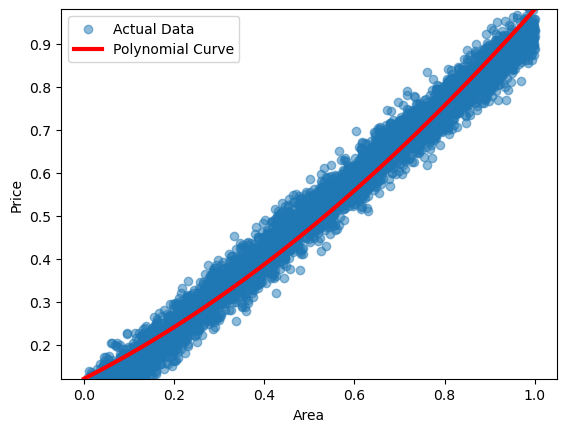

In [33]:
plt.scatter(X_train, y_train, alpha=0.5, label='Actual Data')
plt.plot(x_line, y_line, color='red', linewidth=3, label='Polynomial Curve')

plt.xlabel("Area")
plt.ylabel("Price")
plt.legend()
plt.plot(x_line, y_line, color='red')
plt.ylim(y_line.min(), y_line.max())
plt.show()